# val_02_lickometer — spout-contact detection from pose tracking

Does Lightning-Pose tongue tracking detect a lick, defined as the tongue reaching the spout?

## Two lick definitions

| | Detector | A lick is | Reference |
|---|---|---|---|
| This notebook | tongue within *N* px of a spout | contact with the spout | lickometer |
| Library / `kin_*` | `segment_movements_trimnans` → `annotate_licks_in_kinematics(tol=0.01)` | any tracked tongue excursion matched to a lickometer time | lickometer |

The library's definition does not test whether the tongue reached the spout. `kin_05`'s
"movements without licks" population is unexplained under it; under the contact definition many
of those are protrusions that made no contact.

## Reported quantities

At every parameter combination:

- `pose_recall_vs_lickometer` = matched / (matched + lickometer-only)
- `pose_precision_vs_lickometer` = matched / (matched + pose-only)
- `f1` = 2·matched / (2·matched + pose-only + lickometer-only)

Two operating points are selected from the precision–recall surface — one maximizing precision,
one maximizing recall — alongside the F1 argmax (§6).

The contact definition is what makes precision measurable; the pipeline's `coverage_pct` path
has no precision side (§12). Detector parameters are set from geometry and tongue kinematics
rather than fitted to lickometer labels.

## Scope

- Session `behavior_716325_2024-05-31_10-31-14`.
- Two detectors: **A**, spatial threshold plus refractory filter (the original, unchanged);
  **B**, gap-aware hysteretic detection timestamped at closest approach (§5).
- One session. Thresholds are in pixels, whose physical scale varies with camera position, zoom
  and spout placement; §3.1 reports this session's jaw→spout conversion. Multi-session deferred
  (§12).

## Sections

1. Setup
2. Scoring convention and self-test
3. Load `intermediate_data/`; distance signal `d(t)`; tracking confidence by protrusion phase
4. Implementation A and its properties
5. Implementation B
6. Sweeps, precision–recall surfaces, operating points
7. Sensitivity to the confidence threshold
8. Event time vs threshold; overlap-window choice
9. Inter-lick intervals and the refractory filter
10. Disagreement populations
11. Labeled video clips
12. Relation to `coverage_pct` and `kin_05`

## Local vs Code Ocean

Local: §1, §2, and the synthetic-trace tests in §4.1 and §5. §3 onward needs per-frame keypoints
and NWB lick times, which are not in `data/for_local/`; those cells print a skip message.

## 1. Setup

In [49]:
%matplotlib inline
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from aind_dynamic_foraging_behavior_video_analysis.kinematics.tongue_lickometer_utils import (
    detect_licks,
    filter_timestamps_refractory,
    calculate_metrics,
    calculate_metrics_witheventkeys,
)
from aind_dynamic_foraging_behavior_video_analysis.kinematics.tongue_kinematics_utils import (
    mask_keypoint_data,
    plot_keypoint_confidence_analysis,
)
from aind_dynamic_foraging_behavior_video_analysis.ephys.tongue_ephys import find_session_dir

from plotstyle import apply_style, PALETTE, style_ax, save_fig

apply_style()

### Source module for each imported name

`tongue_lickometer_utils` and `tongue_kinematics_utils` both define `detect_licks`,
`calculate_metrics`, `calculate_metrics_witheventkeys`, `filter_timestamps_refractory`,
`mask_keypoint_data` and `load_keypoints_from_csv`. Four of the six differ between the modules.

| Function | Imported from | Reason |
|---|---|---|
| `detect_licks` | `tongue_lickometer_utils` | vectorized, ~225× faster; signature matches all call sites |
| `calculate_metrics` | `tongue_lickometer_utils` | the `tongue_kinematics_utils` copy returns a `tn` computed by subtracting counts from a timestamp |
| `calculate_metrics_witheventkeys` | `tongue_lickometer_utils` | same |
| `mask_keypoint_data` | `tongue_kinematics_utils` | identical in both |
| `filter_timestamps_refractory` | `tongue_lickometer_utils` | identical in both |

The pending library de-duplication (`TODO.md`, library/repo boundary item) keeps these paths:
`tongue_lickometer_utils` for contact detection and event scoring, `tongue_kinematics_utils` for
keypoint I/O, filtering and segmentation. The package has no `__init__.py` under `kinematics/`,
so full dotted paths are required.

In [50]:
if Path("/root/capsule").exists():
    ENV     = "codeocean"
    SCRATCH = Path("/root/capsule/scratch")
    DATA    = Path("/root/capsule/data")
else:
    ENV     = "local"
    SCRATCH = Path("/Users/mib/Documents/Code/kinematics_analysis/data/for_local").parent
    DATA    = SCRATCH

IS_CO    = ENV == "codeocean"
FIG_DIR  = SCRATCH / "figures" / "val_02_lickometer"
SAVE_FIG = False

# Per-session intermediates — the asset kin_00 / kin_05 / kin_06 read.
SESSION_DIR     = SCRATCH / "session_analysis_mlk"
EXAMPLE_SESSION = "behavior_716325_2024-05-31_10-31-14"

# Masking confidence. 0.90 is the current pipeline's value (tongue_analysis.generate_tongue_dfs);
# 0.80 is what this notebook originally used. Both are run in §7 — see §4, property 2.
CONF_PIPELINE = 0.90
CONF_ORIGINAL = 0.80
CONF          = CONF_PIPELINE

# One color per implementation, used in every comparison figure below.
IMPL_COLOR = {"A": PALETTE["neutral"], "B": PALETTE["pos"]}

print("ENV={}".format(ENV))
if not IS_CO:
    print("Sections 3 and on need per-frame keypoints and NWB lick times "
          "(session_analysis_mlk/<session>/intermediate_data/), which are Code Ocean only.")
    print("Locally, §1, §2 and the synthetic-trace demonstrations in §4/§5 still run.")

ENV=codeocean


## 2. Scoring convention

`calculate_metrics(a, b, window)` names its arguments `ground_truth, detected_events`. This
notebook passes pose events as `a` and lickometer events as `b`, so:

- `tp` = matched pairs
- `fn` = unmatched events from `a` = **pose-only**
- `fp` = unmatched events from `b` = **lickometer-only**

Nothing downstream reads `tp`/`fp`/`fn`: `score_pose_vs_lickometer` and
`classify_pose_vs_lickometer` convert them once, and §6-§10 read only the directional names.

Rates are named for their direction:

- `pose_recall_vs_lickometer` = matched / (matched + lickometer-only) — of lickometer licks, the
  fraction pose found.
- `pose_precision_vs_lickometer` = matched / (matched + pose-only) — of pose contacts, the
  fraction the lickometer confirmed.
- `f1` = 2·matched / (2·matched + pose-only + lickometer-only). Symmetric in the two error
  counts, so unaffected by argument order.

Original cells 19–20 read the slots the other way round: they took `FP_times` from the
lickometer frame and wrote clips to a `false_positive/` directory.

As a scale reference for a fresh run: under this convention the original notebook's stored
cell-16 counts at 30 px / 0.1 s refractory / 0.1 s overlap (`tp=5411, fp=435, fn=180`) are
`pose_recall_vs_lickometer` = 0.926 and `pose_precision_vs_lickometer` = 0.968, with 180
pose-only and 435 lickometer-only events.

In [51]:
def score_pose_vs_lickometer(pose_times, lickometer_times, overlap_window):
    """Score pose-detected contacts against lickometer events, in both directions.

    Wrapper over the library's ``calculate_metrics``. That function names its
    first argument ``ground_truth``; this notebook passes pose events first, so
    its ``fn`` slot holds pose-only events and its ``fp`` slot holds
    lickometer-only events. §2's self-test asserts that mapping.

    Parameters
    ----------
    pose_times : array_like of float
        Contact times from a pose detector, in time-in-session seconds.
    lickometer_times : array_like of float
        Lickometer lick times, same time base.
    overlap_window : float
        Maximum absolute time difference, in seconds, for a pose event and a
        lickometer event to count as the same lick.

    Returns
    -------
    dict
        ``n_matched``, ``n_pose_only``, ``n_lickometer_only``, ``n_pose``,
        ``n_lickometer``, ``pose_recall_vs_lickometer``,
        ``pose_precision_vs_lickometer``, ``f1``, ``overlap_window``.
    """
    tp, fp, fn = calculate_metrics(pose_times, lickometer_times, overlap_window)

    n_matched = tp
    n_pose_only = fn          # unmatched events from the FIRST argument
    n_lickometer_only = fp    # unmatched events from the SECOND argument

    denom_recall = n_matched + n_lickometer_only
    denom_prec = n_matched + n_pose_only
    return {
        "overlap_window": overlap_window,
        "n_matched": n_matched,
        "n_pose_only": n_pose_only,
        "n_lickometer_only": n_lickometer_only,
        "n_pose": n_matched + n_pose_only,
        "n_lickometer": n_matched + n_lickometer_only,
        "pose_recall_vs_lickometer": n_matched / denom_recall if denom_recall else np.nan,
        "pose_precision_vs_lickometer": n_matched / denom_prec if denom_prec else np.nan,
        "f1": (2 * tp) / (2 * tp + fp + fn) if (2 * tp + fp + fn) else np.nan,
    }


def classify_pose_vs_lickometer(pose_times, lickometer_times, overlap_window):
    """Per-event classification of both populations, with direction-carrying labels.

    Wraps ``calculate_metrics_witheventkeys`` and renames its ``True Positive``
    / ``False Negative`` / ``False Positive`` statuses to ``matched``,
    ``pose_only`` and ``lickometer_only``. Same argument order, and therefore
    the same slot mapping, as ``score_pose_vs_lickometer``.

    Parameters
    ----------
    pose_times : array_like of float
        Contact times from a pose detector, in time-in-session seconds.
    lickometer_times : array_like of float
        Lickometer lick times, same time base.
    overlap_window : float
        Coincidence window in seconds.

    Returns
    -------
    pose_events : pandas.DataFrame
        Columns ``time`` and ``status`` (``matched`` or ``pose_only``).
    lickometer_events : pandas.DataFrame
        Columns ``time`` and ``status`` (``matched`` or ``lickometer_only``).
    """
    _, _, _, pose_df, licko_df = calculate_metrics_witheventkeys(
        pose_times, lickometer_times, time_window=overlap_window
    )
    pose_events = pose_df.rename(columns={"Time": "time", "Status": "status"}).replace(
        {"status": {"True Positive": "matched", "False Negative": "pose_only"}}
    )
    lickometer_events = licko_df.rename(columns={"Time": "time", "Status": "status"}).replace(
        {"status": {"True Positive": "matched", "False Positive": "lickometer_only"}}
    )
    return pose_events, lickometer_events


def sweep_overlap_window(pose_times, lickometer_times, overlap_windows, **tags):
    """Score one set of pose events against the lickometer across overlap windows.

    Used by every sweep in §6-§9. A detector run is expensive and scoring is
    not, so the overlap window is swept without re-running the detector.

    Parameters
    ----------
    pose_times : array_like of float
        Contact times from one detector run.
    lickometer_times : array_like of float
        Lickometer lick times.
    overlap_windows : iterable of float
        Coincidence windows to score, in seconds.
    **tags
        Extra columns (detector parameters) copied onto every returned row.

    Returns
    -------
    list of dict
        One row per overlap window, ready for ``pandas.DataFrame``.
    """
    rows = []
    for window in overlap_windows:
        row = score_pose_vs_lickometer(pose_times, lickometer_times, window)
        row.update(tags)
        rows.append(row)
    return rows

### Matcher behavior

`calculate_metrics` matches greedily with two pointers: it pairs the two heads when they fall
within the window, otherwise advances whichever is earlier. It is not mutual-nearest-neighbour,
so with a 100 ms window and 100–150 ms inter-lick intervals an interleaved run can be paired
sub-optimally until the streams resynchronize.

Left unchanged: both implementations are scored with it, so the A–B comparison is unaffected.
§8 uses explicit nearest-neighbour pairing for event-time offsets, where the quantity is timing
rather than agreement counts.

## 3. Load session intermediates

All inputs come from `session_analysis_mlk/<session>/intermediate_data/`, written by
`tongue_analysis.run_batch_analysis`.

**Positions: `kps_raw_*.parquet`, not `tongue_kins.parquet`.** `tongue_kins` is
post-`kinematics_filter`, which cubic-interpolates across NaN gaps and low-pass filters; values
at protrusion edges are interpolation-contaminated, and protrusion edges are where a contact
threshold is crossed.

**Time base: `time_in_session` is read from `tongue_kins`.** `kinematics_filter` returns the
same rows in the same order as its input and asserts the time base is unaltered, so
`tongue_kins` and `kps_raw_tongue_tip_center` are row-aligned. This is the same base as
`nwb_df_licks['timestamps']`, so no offset arithmetic is applied anywhere.

**Spouts.** The `spout_l` keypoint is the animal's right spout and vice versa — the bottom camera
mirrors left/right. Matches the original notebook and `kin_06` §3.

In [52]:
if not IS_CO:
    print("[skip] §3 load: Code Ocean only.")
else:
    inter = find_session_dir(EXAMPLE_SESSION, roots=[SESSION_DIR]) / "intermediate_data"

    # Raw keypoints, full frame set. time_in_session comes from tongue_kins, which
    # kinematics_filter guarantees has the same rows in the same order (it asserts the
    # time base is unaltered and copies extra columns back by position).
    tongue_raw = pd.read_parquet(inter / "kps_raw_tongue_tip_center.parquet")
    tongue_raw["time"] = pd.read_parquet(
        inter / "tongue_kins.parquet", columns=["time_in_session"])["time_in_session"].values

    kps = {"tongue_tip_center": tongue_raw}
    tongue_masked = mask_keypoint_data(kps, "tongue_tip_center", confidence_threshold=CONF)

    lickometer_times = np.sort(
        pd.read_parquet(inter / "nwb_df_licks.parquet")["timestamps"].to_numpy(dtype=float))

    # spout_l is the animal's RIGHT spout (bottom camera mirrors L/R), and vice versa.
    mean_spoutL = pd.read_parquet(inter / "kps_raw_spout_r.parquet")[["x", "y"]].mean()
    mean_spoutR = pd.read_parquet(inter / "kps_raw_spout_l.parquet")[["x", "y"]].mean()
    mean_jaw    = pd.read_parquet(inter / "kps_raw_jaw.parquet")[["x", "y"]].mean()

    duration = tongue_raw["time"].max() - tongue_raw["time"].min()
    print("Frames: {:,}   duration: {:.1f} s   rate: {:.1f} Hz".format(
        len(tongue_raw), duration, len(tongue_raw) / duration))
    print("Tracked at confidence >= {:.2f}: {:,} ({:.1f}%)".format(
        CONF, int(tongue_masked["x"].notna().sum()), 100 * tongue_masked["x"].notna().mean()))
    print("Lickometer events: {:,}".format(len(lickometer_times)))
    print("Spout L {:.1f},{:.1f}   Spout R {:.1f},{:.1f}   Jaw {:.1f},{:.1f}".format(
        mean_spoutL["x"], mean_spoutL["y"], mean_spoutR["x"], mean_spoutR["y"],
        mean_jaw["x"], mean_jaw["y"]))


Frames: 2,689,718   duration: 5379.4 s   rate: 500.0 Hz
Tracked at confidence >= 0.90: 328,598 (12.2%)
Lickometer events: 5,846
Spout L 359.5,248.3   Spout R 361.5,385.1   Jaw 334.5,321.7


### 3.1 Distance to nearest spout, and pixel scale

`d(t)` is the distance from the tongue tip to the nearer spout on every frame. Both
implementations are functions of this signal.

Thresholds are in pixels. Camera position, zoom and spout placement vary across sessions, so a
given pixel value is a different physical distance in each. The jaw→spout distance printed below
converts this session's thresholds to a transferable unit.

In [53]:
def distance_to_nearest_spout(positions, spoutL, spoutR):
    """Per-frame distance from a keypoint to whichever spout is nearer.

    Parameters
    ----------
    positions : pandas.DataFrame
        Frame table with 'x' and 'y' columns. NaN positions propagate to NaN
        distances, which downstream code treats as "not tracked".
    spoutL, spoutR : pandas.Series or dict
        Mappings with 'x' and 'y' giving the two spout positions.

    Returns
    -------
    dist : numpy.ndarray
        Distance in pixels to the nearer spout, one entry per frame.
    nearest : numpy.ndarray of str
        'Left' or 'Right' per frame; NaN-position frames get 'Left' by
        convention and should be read only where ``dist`` is finite.
    """
    xy = positions[["x", "y"]].to_numpy(dtype=float)
    dL = np.linalg.norm(xy - np.array([spoutL["x"], spoutL["y"]], dtype=float), axis=1)
    dR = np.linalg.norm(xy - np.array([spoutR["x"], spoutR["y"]], dtype=float), axis=1)
    dist = np.fmin(dL, dR)
    nearest = np.where(dL <= dR, "Left", "Right")
    return dist, nearest


if not IS_CO:
    print("[skip] §3.1 distance signal: Code Ocean only.")
else:
    d_raw, nearest_raw = distance_to_nearest_spout(tongue_raw, mean_spoutL, mean_spoutR)
    tongue_raw["nearest_spout_distance"] = d_raw
    tongue_raw["nearest_spout"] = nearest_raw

    # Masked copy carries the same columns, with untracked frames set to NaN --
    # §10's per-event traces and the library's own convention both expect this.
    tongue_masked["nearest_spout_distance"] = np.where(
        tongue_masked["x"].notna().to_numpy(), d_raw, np.nan)
    tongue_masked["nearest_spout"] = nearest_raw

    jaw_to_L = float(np.hypot(mean_spoutL["x"] - mean_jaw["x"], mean_spoutL["y"] - mean_jaw["y"]))
    jaw_to_R = float(np.hypot(mean_spoutR["x"] - mean_jaw["x"], mean_spoutR["y"] - mean_jaw["y"]))
    JAW_SPOUT_PX = 0.5 * (jaw_to_L + jaw_to_R)

    print("Jaw to spout (animal's left):  {:.1f} px".format(jaw_to_L))
    print("Jaw to spout (animal's right): {:.1f} px".format(jaw_to_R))
    print("Mean jaw->spout scale:         {:.1f} px  <- this session's conversion factor"
          .format(JAW_SPOUT_PX))
    print()
    print("Thresholds in transferable units, for this session:")
    for thr in (20, 25, 30, 35, 40):
        print("   {:>2d} px = {:.3f} jaw-spout units".format(thr, thr / JAW_SPOUT_PX))

    tracked = tongue_masked["x"].notna().to_numpy()
    print("\nd(t) over tracked frames: median {:.1f} px, 5th pct {:.1f}, 95th pct {:.1f}".format(
        np.nanmedian(d_raw[tracked]), np.nanpercentile(d_raw[tracked], 5),
        np.nanpercentile(d_raw[tracked], 95)))

Jaw to spout (animal's left):  77.6 px
Jaw to spout (animal's right): 68.8 px
Mean jaw->spout scale:         73.2 px  <- this session's conversion factor

Thresholds in transferable units, for this session:
   20 px = 0.273 jaw-spout units
   25 px = 0.341 jaw-spout units
   30 px = 0.410 jaw-spout units
   35 px = 0.478 jaw-spout units
   40 px = 0.546 jaw-spout units

d(t) over tracked frames: median 33.3 px, 5th pct 7.9, 95th pct 64.6


### 3.2 Tracking confidence by protrusion phase

§5's `conf_deny` gate assumes tracking confidence is lower during retraction than during
approach. Measured two ways:

1. Protrusions aligned to closest approach, mean confidence against lag. Lower confidence after
   the apex than before it supports the assumption.
2. `plot_keypoint_confidence_analysis` — confidence distribution, time course, and confidence by
   camera position.

The cell prints whether the assumption holds and what follows for `conf_deny` if it does not.

Protrusions aligned to closest approach: 6,254


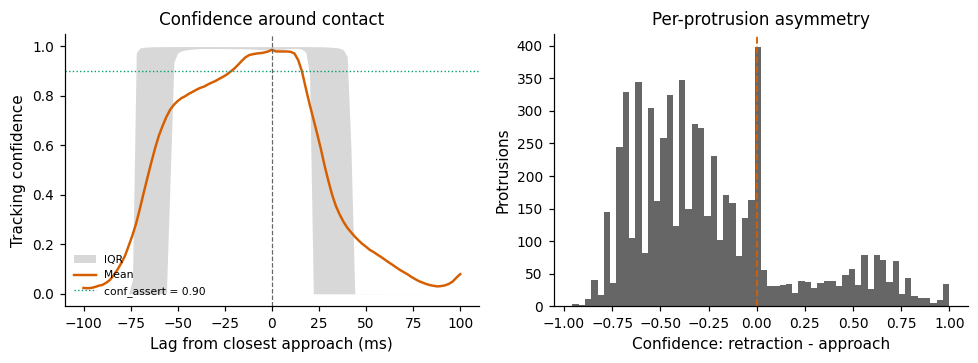


Mean confidence, approach window (-40..-5 ms):  0.900
Mean confidence, retraction window (+5..+40 ms): 0.661
Mean difference (retraction - approach):         -0.238
Protrusions with lower confidence in retraction: 79.5%

HOLDS: confidence is lower during retraction than during approach.
  A retraction frame below conf_assert is still evidence the tongue has left, which is
  what B's conf_deny gate uses.


In [ ]:
def peri_apex_confidence(time, dist, confidence, tracked, contact_radius,
                         half_window_s=0.10, sample_rate=500.0):
    """Align every tracked protrusion to its closest approach and collect confidence.

    A protrusion is a contiguous run of tracked frames whose minimum distance
    falls inside ``contact_radius``; its apex is the frame of minimum distance.
    Confidence is then read from **all** frames in a window around the apex,
    tracked or not, so the trace is not conditioned on the confidence threshold
    that defined the runs.

    Parameters
    ----------
    time, dist, confidence : numpy.ndarray
        Per-frame time (s), distance to nearer spout (px) and tracking
        confidence, all the same length.
    tracked : numpy.ndarray of bool
        Whether each frame has a usable position.
    contact_radius : float
        A run counts as a protrusion only if it comes within this distance, in
        pixels, of a spout.
    half_window_s : float
        Half-width of the peri-apex window, in seconds.
    sample_rate : float
        Frame rate, used to convert the window to a frame count.

    Returns
    -------
    lags : numpy.ndarray
        Lag axis in seconds, negative before the apex.
    conf_matrix : numpy.ndarray
        ``(n_protrusions, n_lags)`` confidence values; protrusions whose window
        would run off either end of the recording are dropped.
    """
    half = int(round(half_window_s * sample_rate))
    lags = np.arange(-half, half + 1) / sample_rate

    edges = np.diff(np.concatenate(([0], tracked.astype(np.int8), [0])))
    starts = np.flatnonzero(edges == 1)
    ends = np.flatnonzero(edges == -1)

    d_search = np.where(tracked, dist, np.inf)
    apexes = []
    for s, e in zip(starts, ends):
        k = s + int(np.argmin(d_search[s:e]))
        if d_search[k] <= contact_radius:
            apexes.append(k)
    apexes = np.asarray(apexes, dtype=int)
    apexes = apexes[(apexes >= half) & (apexes < len(time) - half)]

    if apexes.size == 0:
        return lags, np.empty((0, lags.size))
    idx = apexes[:, None] + np.arange(-half, half + 1)[None, :]
    return lags, confidence[idx]


if not IS_CO:
    print("[skip] §3.2 confidence premise: Code Ocean only.")
else:
    conf_arr = tongue_raw["confidence"].to_numpy(dtype=float)
    lags, conf_matrix = peri_apex_confidence(
        tongue_raw["time"].to_numpy(dtype=float), d_raw, conf_arr, tracked,
        contact_radius=30.0)
    print("Protrusions aligned to closest approach: {:,}".format(conf_matrix.shape[0]))

    approach = (lags >= -0.040) & (lags <= -0.005)
    retract = (lags >= 0.005) & (lags <= 0.040)
    conf_approach = np.nanmean(conf_matrix[:, approach], axis=1)
    conf_retract = np.nanmean(conf_matrix[:, retract], axis=1)
    delta = conf_retract - conf_approach

    fig, axs = plt.subplots(1, 2, figsize=(9, 3.4))
    mean_trace = np.nanmean(conf_matrix, axis=0)
    lo = np.nanpercentile(conf_matrix, 25, axis=0)
    hi = np.nanpercentile(conf_matrix, 75, axis=0)
    axs[0].fill_between(lags * 1e3, lo, hi, color=PALETTE["neutral"], alpha=0.25,
                        lw=0, label="IQR")
    axs[0].plot(lags * 1e3, mean_trace, color=PALETTE["pos"], lw=1.6, label="Mean")
    axs[0].axvline(0, color=PALETTE["neutral"], ls="--", lw=0.8)
    axs[0].axhline(CONF_PIPELINE, color=PALETTE["baseline"], ls=":", lw=0.9,
                   label="conf_assert = {:.2f}".format(CONF_PIPELINE))
    axs[0].set(xlabel="Lag from closest approach (ms)", ylabel="Tracking confidence",
               title="Confidence around contact")
    axs[0].legend(fontsize=7, loc="lower left")
    style_ax(axs[0])

    axs[1].hist(delta, bins=60, color=PALETTE["neutral"])
    axs[1].axvline(0, color=PALETTE["pos"], ls="--", lw=1.2)
    axs[1].set(xlabel="Confidence: retraction - approach", ylabel="Protrusions",
               title="Per-protrusion asymmetry")
    style_ax(axs[1])
    fig.tight_layout()
    save_fig(fig, "confidence_premise", fig_dir=FIG_DIR, save=SAVE_FIG)
    plt.show()

    frac_lower = float(np.mean(delta < 0))
    print("\nMean confidence, approach window (-40..-5 ms):  {:.3f}".format(
        np.nanmean(conf_approach)))
    print("Mean confidence, retraction window (+5..+40 ms): {:.3f}".format(
        np.nanmean(conf_retract)))
    print("Mean difference (retraction - approach):         {:+.3f}".format(np.nanmean(delta)))
    print("Protrusions with lower confidence in retraction: {:.1%}".format(frac_lower))

    PREMISE_HOLDS = bool(np.nanmean(delta) < 0 and frac_lower > 0.5)
    if PREMISE_HOLDS:
        print("\nHOLDS: confidence is lower during retraction than during approach.")
        print("  A retraction frame below conf_assert is still evidence the tongue has left, "
              "which is\n  what B's conf_deny gate uses.")
    else:
        print("\nDOES NOT HOLD on this session.")
        print("  conf_deny is then not separating retraction frames from approach frames. "
              "Set\n  conf_deny == conf_assert and compare: that isolates B's other three "
              "changes.\n  §7 reports the conf_deny sensitivity.")

    # The library's own per-session confidence panel -- distribution, time course, and the
    # spatial heatmap, which is the part the peri-apex trace cannot show.
    plot_keypoint_confidence_analysis(kps, "tongue_tip_center")
    plt.show()

## 4. Implementation A — spatial threshold and refractory filter

`detect_licks` emits an event on each rising-edge crossing into a distance threshold around
either spout. `filter_timestamps_refractory` then removes any event falling within
`t_refractory` of the previous surviving one. Ported unchanged.

In [ ]:
def detect_contacts_threshold(tongue_df, spoutL, spoutR, spatial_threshold, t_refractory):
    """Implementation A: rising-edge threshold crossing, then a refractory filter.

    Behaviorally identical to the original notebook's cells 6/7/14/17 -- both
    library calls are made with the same arguments in the same order. Wrapped
    only so that the two implementations present the same interface to the
    shared sweep code, and so that A's parameters travel together.

    Parameters
    ----------
    tongue_df : pandas.DataFrame
        Masked keypoint table with 'time', 'x', 'y'; untracked frames are NaN
        and are dropped inside ``detect_licks``.
    spoutL, spoutR : pandas.Series
        Spout positions, with 'x' and 'y'.
    spatial_threshold : float
        Contact radius in pixels.
    t_refractory : float
        Events within this many seconds of the previous surviving event are
        deleted. 0 disables the filter.

    Returns
    -------
    numpy.ndarray
        Contact times in seconds, sorted.
    """
    events = detect_licks(tongue_df, spoutL, spoutR, spatial_threshold)
    events = filter_timestamps_refractory(list(events), t_refractory)
    return np.asarray(events, dtype=float)


if not IS_CO:
    print("[skip] §4 worked example: Code Ocean only.")
else:
    A_SPATIAL = 30      # px  -- the original notebook's choice
    A_REFRACTORY = 0.1  # s
    A_OVERLAP = 0.1     # s

    pose_A = detect_contacts_threshold(tongue_masked, mean_spoutL, mean_spoutR,
                                       A_SPATIAL, A_REFRACTORY)
    scored_A = score_pose_vs_lickometer(pose_A, lickometer_times, A_OVERLAP)

    print("\nImplementation A at {} px / {} s refractory / {} s overlap, conf {:.2f}".format(
        A_SPATIAL, A_REFRACTORY, A_OVERLAP, CONF))
    print("  pose contacts        {:,}".format(scored_A["n_pose"]))
    print("  lickometer licks     {:,}".format(scored_A["n_lickometer"]))
    print("  matched              {:,}".format(scored_A["n_matched"]))
    print("  pose-only            {:,}".format(scored_A["n_pose_only"]))
    print("  lickometer-only      {:,}".format(scored_A["n_lickometer_only"]))
    print("  pose_recall_vs_lickometer    {:.3f}".format(
        scored_A["pose_recall_vs_lickometer"]))
    print("  pose_precision_vs_lickometer {:.3f}".format(
        scored_A["pose_precision_vs_lickometer"]))
    print("  f1                           {:.3f}".format(scored_A["f1"]))

### 4.1 Properties of A

Demonstrated below on synthetic traces, which run locally.

1. **`.dropna()` removes the time base.** `detect_licks` drops untracked frames before looping,
   so consecutive entries in the loop may be 2 ms or 2 s apart.
2. **The state re-arms only on a surviving frame outside the threshold.** The confidence mask
   preferentially removes low-confidence frames. When the mask is at least as tight as the
   spatial threshold, no surviving frame lies outside the threshold and the session collapses to
   one event. §7 measures the effect of the 0.80 → 0.90 shift on real data.
3. **Events fire on the rising edge**, so event time varies with the spatial threshold. §8
   measures this against the lickometer.

In [ ]:
def _synthetic_protrusions(duration_s, apex_times, depth_px=5.0, protrusion_s=0.08,
                           rest_px=60.0, noise_px=0.0, sample_rate=500.0, seed=0):
    """Build a synthetic distance trace with triangular protrusions.

    Used only for the demonstrations in §4.1 and the unit tests in §5 -- it runs
    with no session data, which is what makes those cells verifiable locally.

    Parameters
    ----------
    duration_s : float
        Length of the trace in seconds.
    apex_times : iterable of float
        Time of closest approach for each protrusion, in seconds.
    depth_px : float
        Distance to the nearer spout at the apex.
    protrusion_s : float
        Full duration of each protrusion.
    rest_px : float
        Distance when the tongue is retracted.
    noise_px : float
        SD of additive Gaussian noise on the distance signal.
    sample_rate : float
        Frames per second.
    seed : int
        Seed for the noise.

    Returns
    -------
    time, dist, confidence : numpy.ndarray
        Per-frame arrays; confidence is a constant 0.99 and is overwritten by
        callers that want to model masking.
    """
    rng = np.random.default_rng(seed)
    time = np.arange(0.0, duration_s, 1.0 / sample_rate)
    dist = np.full(time.size, float(rest_px))
    for apex in apex_times:
        start = apex - protrusion_s / 2.0
        inside = (time >= start) & (time < start + protrusion_s)
        ramp = np.abs((time[inside] - apex) / (protrusion_s / 2.0))
        dist[inside] = depth_px + (rest_px - depth_px) * ramp
    dist = dist + rng.normal(0.0, noise_px, time.size)
    return time, dist, np.full(time.size, 0.99)


def _as_tongue_df(time, dist, confidence, conf_threshold):
    """Wrap a synthetic distance trace as a masked keypoint table.

    Places the trace on the x axis with the 'left' spout at the origin and the
    'right' spout far away, so ``detect_licks``'s distance-to-nearer-spout
    computation reduces to the supplied ``dist``.

    Parameters
    ----------
    time, dist, confidence : numpy.ndarray
        Per-frame synthetic trace.
    conf_threshold : float
        Frames below this confidence get NaN positions, mimicking
        ``mask_keypoint_data``.

    Returns
    -------
    df : pandas.DataFrame
        Table with 'time', 'x', 'y', 'confidence'.
    spoutL, spoutR : pandas.Series
        The two spout positions to pass to ``detect_licks``.
    """
    x = np.where(confidence >= conf_threshold, dist, np.nan)
    df = pd.DataFrame({"time": time, "x": x, "y": 0.0, "confidence": confidence})
    return df, pd.Series({"x": 0.0, "y": 0.0}), pd.Series({"x": 1e6, "y": 0.0})


# --- Property 3: the rising edge moves with the spatial threshold ---
_t, _d, _c = _synthetic_protrusions(4.0, apex_times=[2.0])
_df, _sL, _sR = _as_tongue_df(_t, _d, _c, 0.90)
print("Property 3 -- A's event time vs spatial threshold (true apex at 2.0000 s):")
for thr in (25, 30, 35, 40):
    ev = detect_contacts_threshold(_df, _sL, _sR, thr, 0.0)
    print("   {:>2d} px: n={}  t={:.4f}  offset {:+6.1f} ms".format(
        thr, len(ev), ev[0], (ev[0] - 2.0) * 1e3))

# --- Property 2: the re-arming failure, and exactly where its boundary is ---
_t, _d, _c = _synthetic_protrusions(6.0, apex_times=[2.0, 2.3, 2.6, 3.0])
print("\nProperty 2 -- A at a 30 px threshold, 4 true protrusions,")
print("               varying where the confidence mask cuts:")
for mask_at in (45, 35, 30, 25):
    conf = np.where(_d < mask_at, 0.99, 0.10)   # tracked only within mask_at px of the spout
    _df, _sL, _sR = _as_tongue_df(_t, _d, conf, 0.90)
    ev = detect_contacts_threshold(_df, _sL, _sR, 30, 0.0)
    note = "" if len(ev) == 4 else "   <- collapsed"
    print("   tracked only within {:>2d} px: A detects {} event(s){}".format(
        mask_at, len(ev), note))
print("   The collapse begins where the mask becomes as tight as the 30 px threshold:")
print("   with no surviving frame outside it, the state never re-arms.")

# --- Property 1: a dropout inside a contact is invisible ---
# One long contact (the tongue is inside 30 px from t=0.77 to t=1.23), with tracking
# lost for 80 ms in the middle of it. §5's T4 runs B on this identical trace.
_t, _d, _c = _synthetic_protrusions(4.0, apex_times=[1.0], protrusion_s=1.0)
conf = _c.copy()
conf[(_t > 0.90) & (_t < 0.98)] = 0.10
_df, _sL, _sR = _as_tongue_df(_t, _d, conf, 0.90)
ev = detect_contacts_threshold(_df, _sL, _sR, 30, 0.0)
print("\nProperty 1 -- 80 ms tracking dropout in the middle of one long contact:")
print("   A detects {} event(s). After .dropna() the frames either side of the".format(len(ev)))
print("   dropout are adjacent and 80 ms apart, indistinguishable from two")
print("   consecutive frames 2 ms apart.")

## 5. Implementation B — gap-aware hysteretic contact detection

Four changes to A:

1. Works on `d(t)` over all frames; an untracked gap longer than `max_gap_s` closes an open
   contact.
2. Events are timestamped at closest approach rather than first entry, making event time
   independent of the entry threshold.
3. Hysteresis: a contact opens at `d ≤ enter` and closes at `d > enter + dead_band`.
4. Asymmetric confidence: `conf ≥ conf_assert` to open a contact, `conf ≥ conf_deny` to count a
   frame as tracked and therefore to close one. §3.2 measures the assumption behind this.

Fixed parameters:

| Parameter | Value | Source |
|---|---|---|
| `max_gap_s` | 0.020 s | `segment_movements_trimnans(max_dropped_frames=10)` at 500 Hz |
| `conf_assert` | 0.90 | pipeline masking value (`tongue_analysis.generate_tongue_dfs`) |
| `conf_deny` | 0.60 | not tuned; sensitivity reported in §7 |

Dead-band bounds:

- **Lower — tracker position noise.** `pixel_error.ipynb` reports `tongue_tip_center` =
  3.67 ± 2.02 px against human labels, so the band must exceed roughly 4–6 px or a stationary
  tongue crosses it.
- **Upper — a full retraction excursion** (§3.1's jaw→spout distance), above which genuine
  retractions stop crossing the exit threshold.

Grid: 5–25 px. §9 tests whether F1 is flat across that range.

In [ ]:
def detect_contacts_hysteretic(time, dist, confidence, enter_px, dead_band_px,
                               conf_assert=0.90, conf_deny=0.60, max_gap_s=0.020):
    """Implementation B: gap-aware hysteretic contact detection at closest approach.

    Works on the distance-to-nearest-spout signal over **all** frames, so
    untracked stretches are visible to the decision rule instead of being
    dropped. A contact opens on a confident frame inside ``enter_px`` and closes
    either on a tracked frame beyond ``enter_px + dead_band_px`` or on an
    untracked gap longer than ``max_gap_s``; each contiguous contact yields one
    event, timestamped at its frame of closest approach.

    Fully vectorized -- no Python loop over frames -- via running maxima of the
    last "open" and last "close" frame indices.

    Parameters
    ----------
    time : numpy.ndarray
        Per-frame time in seconds, ascending.
    dist : numpy.ndarray
        Per-frame distance to the nearer spout, in pixels. NaN counts as
        untracked.
    confidence : numpy.ndarray
        Per-frame tracking confidence.
    enter_px : float
        Distance at or below which a confident frame opens a contact.
    dead_band_px : float
        Width of the hysteresis band. A contact closes only beyond
        ``enter_px + dead_band_px``. 0 reduces B to a non-hysteretic detector.
    conf_assert : float
        Confidence required to *open* a contact.
    conf_deny : float
        Confidence required to count a frame as tracked, and so to *close* a
        contact or to reset the gap clock. Must not exceed ``conf_assert``.
    max_gap_s : float
        An untracked stretch longer than this closes an open contact.

    Returns
    -------
    event_times : numpy.ndarray
        One time per contact, at closest approach, in seconds.
    event_dists : numpy.ndarray
        The distance at each of those closest approaches, in pixels.
    """
    time = np.asarray(time, dtype=float)
    dist = np.asarray(dist, dtype=float)
    confidence = np.asarray(confidence, dtype=float)
    if conf_deny > conf_assert:
        raise ValueError("conf_deny ({}) must not exceed conf_assert ({}) -- the gate is "
                         "asymmetric by design".format(conf_deny, conf_assert))
    if dead_band_px < 0:
        raise ValueError("dead_band_px must be >= 0")

    n = time.size
    if n == 0:
        return np.empty(0), np.empty(0)
    exit_px = enter_px + dead_band_px
    idx = np.arange(n)

    tracked = (confidence >= conf_deny) & np.isfinite(dist)

    # Time since the last tracked frame (0 on tracked frames, inf before the first).
    last_tracked = np.maximum.accumulate(np.where(tracked, idx, -1))
    seen = last_tracked >= 0
    gap = np.full(n, np.inf)
    gap[seen] = time[seen] - time[last_tracked[seen]]

    opens = tracked & (dist <= enter_px) & (confidence >= conf_assert)
    closes = (tracked & (dist > exit_px)) | ((~tracked) & (gap > max_gap_s))

    # A frame is inside a contact iff the most recent "open" is more recent than
    # the most recent "close".
    last_open = np.maximum.accumulate(np.where(opens, idx, -1))
    last_close = np.maximum.accumulate(np.where(closes, idx, -1))
    inside = last_open > last_close
    if not inside.any():
        return np.empty(0), np.empty(0)

    edges = np.diff(np.concatenate(([0], inside.astype(np.int8), [0])))
    starts = np.flatnonzero(edges == 1)
    ends = np.flatnonzero(edges == -1)

    # Closest approach within each contact, ignoring untracked frames.
    searchable = np.where(tracked, dist, np.inf)
    apex = np.array([s + int(np.argmin(searchable[s:e])) for s, e in zip(starts, ends)])
    return time[apex], dist[apex]

In [ ]:
# --- §5 unit tests for B: synthetic traces, no session data, runs locally ---
SAMPLE_RATE = 500.0

# T1: one clean protrusion -> exactly one event, at closest approach, at every threshold.
_t, _d, _c = _synthetic_protrusions(4.0, apex_times=[2.0])
print("T1 -- B's event time vs entry threshold (true apex at 2.0000 s):")
for enter in (25, 30, 35, 40):
    ev, _ = detect_contacts_hysteretic(_t, _d, _c, enter, 10)
    print("   {:>2d} px: n={}  t={:.4f}  offset {:+6.1f} ms".format(
        enter, len(ev), ev[0], (ev[0] - 2.0) * 1e3))
    assert len(ev) == 1 and abs(ev[0] - 2.0) < 1e-9

# T2: a noisy protrusion that chatters across the entry threshold.
_t, _d, _c = _synthetic_protrusions(4.0, apex_times=[2.0], noise_px=3.0, seed=1)
_df, _sL, _sR = _as_tongue_df(_t, _d, _c, 0.90)
nA = len(detect_contacts_threshold(_df, _sL, _sR, 30, 0.0))
nB = len(detect_contacts_hysteretic(_t, _d, _c, 30, 10)[0])
print("\nT2 -- one noisy protrusion (position noise SD 3 px), refractory filter off:")
print("   A detects {}, B detects {}  (truth 1)".format(nA, nB))
assert nB == 1

# T3: A's re-arming failure -- the mask is as tight as the threshold.
_t, _d, _c = _synthetic_protrusions(6.0, apex_times=[2.0, 2.3, 2.6, 3.0])
conf = np.where(_d < 30, 0.99, 0.10)
_df, _sL, _sR = _as_tongue_df(_t, _d, conf, 0.90)
nA = len(detect_contacts_threshold(_df, _sL, _sR, 30, 0.0))
nB = len(detect_contacts_hysteretic(_t, _d, conf, 30, 10)[0])
print("\nT3 -- tongue tracked only within 30 px, 30 px threshold, 4 true protrusions:")
print("   A detects {}, B detects {}".format(nA, nB))
assert nB == 4, "B should be immune to the re-arming failure"

# T4: an untracked gap inside a contact terminates it (change 1).
# The identical trace §4.1's property-1 demonstration used, where A detected 1 event.
_t, _d, _c = _synthetic_protrusions(4.0, apex_times=[1.0], protrusion_s=1.0)
conf = _c.copy()
conf[(_t > 0.90) & (_t < 0.98)] = 0.10
ev, _ = detect_contacts_hysteretic(_t, _d, conf, 30, 10)
print("\nT4 -- 80 ms dropout inside one long contact (same trace as §4.1, property 1):")
print("   B reports {} events at {} s; A reported 1. max_gap_s decides whether".format(
    len(ev), np.round(ev, 3).tolist()))
print("   a gap ends a contact.")
assert len(ev) == 2, "an untracked gap longer than max_gap_s must terminate a contact"

# T5: the vectorized form agrees with an explicit frame loop.
def _loop_reference(time, dist, confidence, enter_px, dead_band_px,
                    conf_assert=0.90, conf_deny=0.60, max_gap_s=0.020):
    """Straightforward frame loop, as a check on the vectorized implementation."""
    exit_px = enter_px + dead_band_px
    tracked = (confidence >= conf_deny) & np.isfinite(dist)
    runs, current, inside, last_tracked = [], [], False, None
    for i in range(time.size):
        if tracked[i]:
            last_tracked = time[i]
            if not inside:
                if dist[i] <= enter_px and confidence[i] >= conf_assert:
                    inside, current = True, [i]
            elif dist[i] > exit_px:
                runs.append(current); inside, current = False, []
            else:
                current.append(i)
        elif inside and last_tracked is not None and (time[i] - last_tracked) > max_gap_s:
            runs.append(current); inside, current = False, []
    if inside and current:
        runs.append(current)
    out = []
    for run in runs:
        run = np.asarray(run)
        out.append(time[run[int(np.argmin(np.where(tracked[run], dist[run], np.inf)))]])
    return np.asarray(out)

rng = np.random.default_rng(7)
_t, _d, _c = _synthetic_protrusions(20.0, apex_times=np.arange(1.0, 19.0, 0.37),
                                    noise_px=4.0, seed=3)
conf = np.clip(rng.normal(0.9, 0.15, _t.size), 0.0, 1.0)
ev_vec, _ = detect_contacts_hysteretic(_t, _d, conf, 30, 10)
ev_loop = _loop_reference(_t, _d, conf, 30, 10)
assert len(ev_vec) == len(ev_loop) and np.allclose(ev_vec, ev_loop), "vectorized != loop"
print("\nT5 -- vectorized vs explicit loop on a 20 s noisy trace: {} events, identical.".format(
    len(ev_vec)))

print("\nAll Implementation B unit tests passed.")

In [ ]:
if not IS_CO:
    print("[skip] §5 worked example: Code Ocean only.")
else:
    B_ENTER = 30        # px, matched to A's spatial threshold for a like-for-like comparison
    B_DEAD_BAND = 10    # px, comfortably above the ~4-6 px tracker noise scale
    B_CONF_ASSERT = CONF_PIPELINE
    B_CONF_DENY = 0.60
    B_MAX_GAP_S = 0.020

    time_arr = tongue_raw["time"].to_numpy(dtype=float)
    conf_arr = tongue_raw["confidence"].to_numpy(dtype=float)

    pose_B, pose_B_dist = detect_contacts_hysteretic(
        time_arr, d_raw, conf_arr, B_ENTER, B_DEAD_BAND,
        conf_assert=B_CONF_ASSERT, conf_deny=B_CONF_DENY, max_gap_s=B_MAX_GAP_S)
    scored_B = score_pose_vs_lickometer(pose_B, lickometer_times, A_OVERLAP)

    print("Implementation B at enter {} px / dead band {} px / {} s overlap".format(
        B_ENTER, B_DEAD_BAND, A_OVERLAP))
    print("  conf_assert {:.2f}, conf_deny {:.2f}, max_gap {:.0f} ms".format(
        B_CONF_ASSERT, B_CONF_DENY, B_MAX_GAP_S * 1e3))
    print()
    header = "{:<32} {:>12} {:>12}".format("", "A (30 px)", "B (30/10 px)")
    print(header)
    print("-" * len(header))
    for label, key, fmt in [
        ("pose contacts", "n_pose", "{:>12,}"),
        ("matched", "n_matched", "{:>12,}"),
        ("pose-only", "n_pose_only", "{:>12,}"),
        ("lickometer-only", "n_lickometer_only", "{:>12,}"),
        ("pose_recall_vs_lickometer", "pose_recall_vs_lickometer", "{:>12.3f}"),
        ("pose_precision_vs_lickometer", "pose_precision_vs_lickometer", "{:>12.3f}"),
        ("f1 (summary only)", "f1", "{:>12.3f}"),
    ]:
        print(("{:<32}" + fmt + fmt).format(label, scored_A[key], scored_B[key]))
    print("\nLickometer events: {:,}".format(scored_A["n_lickometer"]))
    print("Median closest-approach distance at B's events: {:.1f} px".format(
        float(np.median(pose_B_dist))))

## 6. Sweeps, precision–recall surfaces, operating points

Figure 2 plots each detector parameter combination as a point in (recall, precision), with the
Pareto frontier and three marked points:

- `OP_FLAG_MISSES` — maximum `pose_precision_vs_lickometer` subject to recall ≥ 0.80.
- `OP_FLAG_FALSE_TRIGGERS` — maximum `pose_recall_vs_lickometer` subject to precision ≥ 0.80.
- `F1_ARGMAX`.

The overlap window is a scoring parameter, not a detector parameter, and is held at 100 ms for
operating-point selection — widening it raises agreement for any detector. §8 examines whether
100 ms is the right choice. The full overlap sweep is retained in `sweeps` for §8.

Grids: **A** = spatial 10–50 px × refractory 0–0.10 s. **B** = enter 10–50 px × dead band
5–25 px, no refractory filter (§9 tests whether one is needed). Both are scored across overlap
0.005–0.25 s.

In [ ]:
import contextlib
import io

SPATIAL_THRESHOLDS = np.arange(10, 51, 5)          # px -- the original notebook's grid
T_REFRACTORY_VALUES = np.arange(0, 0.11, 0.01)     # s
OVERLAP_WINDOWS = np.arange(0.005, 0.251, 0.005)   # s
DEAD_BANDS = np.array([5, 10, 15, 20, 25])         # px -- noise scale up to well above it

if not IS_CO:
    print("[skip] §6 sweeps: Code Ocean only.")
else:
    import time as _time

    # --- Implementation A -----------------------------------------------------
    # filter_timestamps_refractory prints a line per call; 99 calls is noise, so the
    # sweep is run inside a redirect. The function itself is untouched.
    _t_start = _time.time()
    rows_A = []
    with contextlib.redirect_stdout(io.StringIO()):
        for spatial in SPATIAL_THRESHOLDS:
            raw_events = detect_licks(tongue_masked, mean_spoutL, mean_spoutR, spatial)
            for t_refractory in T_REFRACTORY_VALUES:
                events = np.asarray(
                    filter_timestamps_refractory(list(raw_events), t_refractory), dtype=float)
                rows_A.extend(sweep_overlap_window(
                    events, lickometer_times, OVERLAP_WINDOWS,
                    impl="A", spatial_threshold=spatial, t_refractory=t_refractory,
                    dead_band=np.nan))
    sweep_A = pd.DataFrame(rows_A)
    print("A: {:,} scorings from {} detector runs in {:.1f} s".format(
        len(sweep_A), len(SPATIAL_THRESHOLDS), _time.time() - _t_start))

    # --- Implementation B -----------------------------------------------------
    _t_start = _time.time()
    rows_B = []
    for enter in SPATIAL_THRESHOLDS:
        for dead_band in DEAD_BANDS:
            events, _ = detect_contacts_hysteretic(
                time_arr, d_raw, conf_arr, enter, dead_band,
                conf_assert=B_CONF_ASSERT, conf_deny=B_CONF_DENY, max_gap_s=B_MAX_GAP_S)
            rows_B.extend(sweep_overlap_window(
                events, lickometer_times, OVERLAP_WINDOWS,
                impl="B", spatial_threshold=enter, t_refractory=0.0,
                dead_band=dead_band))
    sweep_B = pd.DataFrame(rows_B)
    print("B: {:,} scorings from {} detector runs in {:.1f} s".format(
        len(sweep_B), len(SPATIAL_THRESHOLDS) * len(DEAD_BANDS), _time.time() - _t_start))

    sweeps = pd.concat([sweep_A, sweep_B], ignore_index=True)
    print("\nBest F1 per implementation (for reference only -- see the surface below):")
    for impl, grp in sweeps.groupby("impl"):
        best = grp.loc[grp["f1"].idxmax()]
        print("  {}: f1={:.4f} at spatial={:.0f} px, dead_band={}, refractory={:.2f} s, "
              "overlap={:.3f} s".format(
                  impl, best["f1"], best["spatial_threshold"],
                  "n/a" if np.isnan(best["dead_band"]) else "{:.0f} px".format(best["dead_band"]),
                  best["t_refractory"], best["overlap_window"]))

In [ ]:
def pareto_frontier(recall, precision):
    """Indices of the non-dominated points of a recall/precision cloud.

    A point is dominated if another point is at least as good on both axes and
    strictly better on one.

    Parameters
    ----------
    recall, precision : numpy.ndarray
        Equal-length arrays of the two rates.

    Returns
    -------
    numpy.ndarray of int
        Indices of non-dominated points, sorted by recall.
    """
    order = np.argsort(-recall)
    keep, best_precision = [], -np.inf
    for i in order:
        if precision[i] > best_precision:
            keep.append(i)
            best_precision = precision[i]
    return np.asarray(keep)[np.argsort(recall[keep])]


def pick_operating_points(frame, recall_floor=0.80, precision_floor=0.80):
    """Select the two QC operating points from a swept results frame.

    Each maximizes one rate subject to the other staying above a floor.

    Parameters
    ----------
    frame : pandas.DataFrame
        Sweep rows carrying ``pose_recall_vs_lickometer`` and
        ``pose_precision_vs_lickometer``.
    recall_floor : float
        Minimum recall the high-precision point must retain.
    precision_floor : float
        Minimum precision the high-recall point must retain.

    Returns
    -------
    dict
        ``OP_FLAG_MISSES``, ``OP_FLAG_FALSE_TRIGGERS`` and ``F1_ARGMAX``, each a
        row of ``frame`` (or None where the floor cannot be met).
    """
    ok_recall = frame[frame["pose_recall_vs_lickometer"] >= recall_floor]
    ok_precision = frame[frame["pose_precision_vs_lickometer"] >= precision_floor]
    return {
        "OP_FLAG_MISSES": (
            ok_recall.loc[ok_recall["pose_precision_vs_lickometer"].idxmax()]
            if len(ok_recall) else None),
        "OP_FLAG_FALSE_TRIGGERS": (
            ok_precision.loc[ok_precision["pose_recall_vs_lickometer"].idxmax()]
            if len(ok_precision) else None),
        "F1_ARGMAX": frame.loc[frame["f1"].idxmax()],
    }


def describe_operating_point(row):
    """One-line description of a sweep row's parameters."""
    if row is None:
        return "none (floor could not be met)"
    band = ("" if np.isnan(row["dead_band"])
            else ", dead band {:.0f} px".format(row["dead_band"]))
    refr = ("" if row["t_refractory"] == 0
            else ", refractory {:.2f} s".format(row["t_refractory"]))
    return ("{:.0f} px{}{}, overlap {:.3f} s -> recall {:.3f}, precision {:.3f}, f1 {:.3f}"
            .format(row["spatial_threshold"], band, refr, row["overlap_window"],
                    row["pose_recall_vs_lickometer"], row["pose_precision_vs_lickometer"],
                    row["f1"]))


RECALL_FLOOR = 0.80
PRECISION_FLOOR = 0.80
# Scoring parameter, held fixed -- see the note above. §8 revisits whether it is justified.
OP_OVERLAP = 0.100

if not IS_CO:
    print("[skip] §6 figure 2 (precision-recall surface): Code Ocean only.")
else:
    operating_points = {}
    fig, axs = plt.subplots(1, 2, figsize=(10, 4.4), sharex=True, sharey=True)
    for ax, impl in zip(axs, ["A", "B"]):
        grp = sweeps[(sweeps["impl"] == impl)
                     & np.isclose(sweeps["overlap_window"], OP_OVERLAP)]
        recall = grp["pose_recall_vs_lickometer"].to_numpy()
        precision = grp["pose_precision_vs_lickometer"].to_numpy()

        sc = ax.scatter(recall, precision, c=grp["spatial_threshold"], cmap="viridis",
                        s=6, alpha=0.45, lw=0)
        front = pareto_frontier(recall, precision)
        ax.plot(recall[front], precision[front], color=PALETTE["all"], lw=1.2,
                label="Pareto frontier")

        ops = pick_operating_points(grp, RECALL_FLOOR, PRECISION_FLOOR)
        operating_points[impl] = ops
        marks = [("OP_FLAG_MISSES", "*", PALETTE["pos"], 220),
                 ("OP_FLAG_FALSE_TRIGGERS", "P", PALETTE["neg"], 110),
                 ("F1_ARGMAX", "x", PALETTE["neutral"], 80)]
        for name, marker, color, size in marks:
            row = ops[name]
            if row is None:
                continue
            ax.scatter([row["pose_recall_vs_lickometer"]],
                       [row["pose_precision_vs_lickometer"]],
                       marker=marker, s=size, c=color, edgecolors="k", linewidths=0.5,
                       zorder=6, label=name)

        ax.axhline(PRECISION_FLOOR, color=PALETTE["neutral"], ls=":", lw=0.7)
        ax.axvline(RECALL_FLOOR, color=PALETTE["neutral"], ls=":", lw=0.7)
        ax.set(xlabel="pose_recall_vs_lickometer",
               title="Implementation {}".format(impl))
        style_ax(ax)
    axs[0].set_ylabel("pose_precision_vs_lickometer")
    axs[0].legend(fontsize=7, loc="lower left")
    fig.colorbar(sc, ax=axs, label="Spatial / entry threshold (px)", fraction=0.03, pad=0.02)
    fig.suptitle("Figure 2 - Precision-recall surface at a {:.0f} ms overlap window, {}"
                 .format(OP_OVERLAP * 1e3, EXAMPLE_SESSION), y=1.02)
    save_fig(fig, "fig2_precision_recall_surface", fig_dir=FIG_DIR, save=SAVE_FIG)
    plt.show()

    for impl in ["A", "B"]:
        print("\nImplementation {} operating points "
              "(recall floor {:.2f}, precision floor {:.2f}, overlap fixed at {:.0f} ms):"
              .format(impl, RECALL_FLOOR, PRECISION_FLOOR, OP_OVERLAP * 1e3))
        for name in ["OP_FLAG_MISSES", "OP_FLAG_FALSE_TRIGGERS", "F1_ARGMAX"]:
            print("  {:<24} {}".format(name, describe_operating_point(
                operating_points[impl][name])))

## 7. Sensitivity to the confidence threshold — figure 1

A is run at `mask_keypoint_data(confidence_threshold=)` of 0.80, the original notebook's value,
and 0.90, the pipeline's. The matched parameter for B is `conf_assert`; `conf_deny` stays at
0.60 in both runs, so the same quantity varies in each.

Property 2 of §4.1 predicts A's detection count and ILI distribution shift between the two
values. For B, frames between `conf_deny` and `conf_assert` still close a contact, so the shift
should be smaller.

`conf_deny` sensitivity is printed as a table at the end of the cell rather than swept as an
axis.

In [ ]:
if not IS_CO:
    print("[skip] §7 figure 1 (confidence sensitivity): Code Ocean only.")
else:
    CONF_VALUES = [CONF_ORIGINAL, CONF_PIPELINE]
    conf_runs = {}
    with contextlib.redirect_stdout(io.StringIO()):
        for conf_value in CONF_VALUES:
            masked = mask_keypoint_data(kps, "tongue_tip_center",
                                        confidence_threshold=conf_value)
            conf_runs[("A", conf_value)] = detect_contacts_threshold(
                masked, mean_spoutL, mean_spoutR, A_SPATIAL, A_REFRACTORY)
            conf_runs[("B", conf_value)] = detect_contacts_hysteretic(
                time_arr, d_raw, conf_arr, B_ENTER, B_DEAD_BAND,
                conf_assert=conf_value, conf_deny=B_CONF_DENY,
                max_gap_s=B_MAX_GAP_S)[0]

    fig, axs = plt.subplots(1, 2, figsize=(10, 3.8))

    labels = ["{} @ {:.2f}".format(impl, cv) for impl in ["A", "B"] for cv in CONF_VALUES]
    counts = [len(conf_runs[(impl, cv)]) for impl in ["A", "B"] for cv in CONF_VALUES]
    colors = [IMPL_COLOR[impl] for impl in ["A", "B"] for _ in CONF_VALUES]
    bars = axs[0].bar(labels, counts, color=colors, edgecolor="k", linewidth=0.4)
    # The lower confidence bar is drawn faded, the pipeline's value solid.
    for bar, conf_value in zip(bars, CONF_VALUES * 2):
        bar.set_alpha(0.55 if conf_value == CONF_ORIGINAL else 1.0)
    axs[0].axhline(len(lickometer_times), color=PALETTE["accent"], ls="--", lw=1.2,
                   label="Lickometer ({:,})".format(len(lickometer_times)))
    for bar, count in zip(bars, counts):
        axs[0].annotate("{:,}".format(count), (bar.get_x() + bar.get_width() / 2, count),
                        ha="center", va="bottom", fontsize=7)
    axs[0].set(ylabel="Detected contacts", xlabel="Implementation @ confidence bar",
               title="Detection count")
    axs[0].legend(fontsize=7)
    style_ax(axs[0])

    for impl in ["A", "B"]:
        for cv, ls in zip(CONF_VALUES, [":", "-"]):
            ili = np.diff(np.sort(conf_runs[(impl, cv)]))
            axs[1].plot(np.sort(ili), np.arange(1, ili.size + 1) / ili.size,
                        color=IMPL_COLOR[impl], ls=ls, lw=1.3,
                        label="{} @ {:.2f}".format(impl, cv))
    licko_ili = np.diff(lickometer_times)
    axs[1].plot(np.sort(licko_ili), np.arange(1, licko_ili.size + 1) / licko_ili.size,
                color=PALETTE["accent"], lw=1.3, label="Lickometer")
    axs[1].set(xlim=(0, 0.5), xlabel="Inter-lick interval (s)",
               ylabel="Cumulative probability", title="ILI distribution")
    axs[1].legend(fontsize=7, loc="lower right")
    style_ax(axs[1])

    fig.suptitle("Figure 1 - Sensitivity to the confidence bar", y=1.02)
    fig.tight_layout()
    save_fig(fig, "fig1_confidence_sensitivity", fig_dir=FIG_DIR, save=SAVE_FIG)
    plt.show()

    print("Change in detected contacts from confidence {:.2f} -> {:.2f}:".format(*CONF_VALUES))
    shifts = {}
    for impl in ["A", "B"]:
        lo, hi = (len(conf_runs[(impl, cv)]) for cv in CONF_VALUES)
        shifts[impl] = abs(hi - lo) / lo
        print("  {}: {:,} -> {:,}  ({:+.1%})".format(impl, lo, hi, (hi - lo) / lo))
    print("\nSub-100 ms ILI fraction (the population the refractory filter exists to delete):")
    for impl in ["A", "B"]:
        for cv in CONF_VALUES:
            ili = np.diff(np.sort(conf_runs[(impl, cv)]))
            print("  {} @ {:.2f}: {:.2%}".format(impl, cv, float(np.mean(ili < 0.1))))

    if shifts["B"] < shifts["A"]:
        print("\nB is less sensitive than A to the confidence threshold "
              "({:.1%} vs {:.1%}).".format(shifts["B"], shifts["A"]))
    else:
        print("\nB is not less sensitive than A to the confidence threshold "
              "({:.1%} vs {:.1%}).".format(shifts["B"], shifts["A"]))
        print("  Together with a failed §3.2 check, that would leave change 4 (the "
              "asymmetric\n  confidence gate) unsupported.")

    # conf_deny sensitivity, reported rather than swept.
    print("\nconf_deny sensitivity for B (enter {} px, dead band {} px, conf_assert {:.2f}):"
          .format(B_ENTER, B_DEAD_BAND, B_CONF_ASSERT))
    for conf_deny in (0.40, 0.50, 0.60, 0.70, 0.80):
        events, _ = detect_contacts_hysteretic(
            time_arr, d_raw, conf_arr, B_ENTER, B_DEAD_BAND,
            conf_assert=B_CONF_ASSERT, conf_deny=conf_deny, max_gap_s=B_MAX_GAP_S)
        scored = score_pose_vs_lickometer(events, lickometer_times, A_OVERLAP)
        print("  conf_deny {:.2f}: {:,} contacts, recall {:.3f}, precision {:.3f}".format(
            conf_deny, len(events), scored["pose_recall_vs_lickometer"],
            scored["pose_precision_vs_lickometer"]))

## 8. Event time vs threshold — figure 3

A timestamps on the rising edge, so its event time varies with the spatial threshold. B
timestamps at closest approach, which is threshold-independent by construction.

If A's latency varies with the threshold, the spatial and overlap axes of the §6 sweep are
coupled: part of the variation along the diagonal of the original F1 heatmaps is the overlap
window absorbing a latency shift rather than a change in detection quality. The original
notebook noted the symptom without this explanation (cell 11: *"maximizing both the refractory
filter value, and the overlap threshold value, produces best performance; however, unsure if
this is truly warranted"*).

Panel 2 reports the smallest overlap window reaching 95% of each implementation's asymptotic
recall — the basis for choosing the window rather than inheriting 100 ms.

On synthetic traces A fires 14–24 ms early with about 10 ms of drift over 25–40 px (§4.1). Real
magnitudes depend on protrusion kinematics.

Offsets use nearest-neighbour pairing within the window, not the greedy matcher of §2; the
counts in §6 and §10 use the greedy matcher.

In [ ]:
def nearest_neighbour_offsets(pose_times, lickometer_times, window):
    """Signed time offsets from pose events to their nearest lickometer event.

    Explicitly nearest-neighbour, unlike the greedy matcher inside
    ``calculate_metrics`` -- see §2 and §8. Pose events with no lickometer
    event inside ``window`` are dropped.

    Parameters
    ----------
    pose_times : array_like of float
        Pose contact times.
    lickometer_times : numpy.ndarray
        Sorted lickometer lick times.
    window : float
        Maximum absolute offset, in seconds, for a pair to be reported.

    Returns
    -------
    numpy.ndarray
        Signed offsets in seconds; positive means the pose event is later.
    """
    pose_times = np.asarray(pose_times, dtype=float)
    if pose_times.size == 0 or lickometer_times.size == 0:
        return np.empty(0)
    pos = np.searchsorted(lickometer_times, pose_times)
    left = np.clip(pos - 1, 0, lickometer_times.size - 1)
    right = np.clip(pos, 0, lickometer_times.size - 1)
    d_left = pose_times - lickometer_times[left]
    d_right = pose_times - lickometer_times[right]
    offsets = np.where(np.abs(d_left) <= np.abs(d_right), d_left, d_right)
    return offsets[np.abs(offsets) <= window]


if not IS_CO:
    print("[skip] §8 figure 3 (event-time accuracy): Code Ocean only.")
else:
    OFFSET_WINDOW = 0.10
    offset_rows = []
    with contextlib.redirect_stdout(io.StringIO()):
        for threshold in SPATIAL_THRESHOLDS:
            runs = {
                "A": detect_contacts_threshold(tongue_masked, mean_spoutL, mean_spoutR,
                                               threshold, 0.0),
                "B": detect_contacts_hysteretic(
                    time_arr, d_raw, conf_arr, threshold, B_DEAD_BAND,
                    conf_assert=B_CONF_ASSERT, conf_deny=B_CONF_DENY,
                    max_gap_s=B_MAX_GAP_S)[0],
            }
            for impl, events in runs.items():
                offsets = nearest_neighbour_offsets(events, lickometer_times, OFFSET_WINDOW)
                if offsets.size == 0:
                    continue
                offset_rows.append({
                    "impl": impl, "threshold": threshold, "n_paired": offsets.size,
                    "median_ms": float(np.median(offsets)) * 1e3,
                    "q25_ms": float(np.percentile(offsets, 25)) * 1e3,
                    "q75_ms": float(np.percentile(offsets, 75)) * 1e3,
                })
    offsets_df = pd.DataFrame(offset_rows)

    fig, axs = plt.subplots(1, 2, figsize=(10, 3.8))

    for impl in ["A", "B"]:
        grp = offsets_df[offsets_df["impl"] == impl]
        axs[0].plot(grp["threshold"], grp["median_ms"], "-o", ms=4,
                    color=IMPL_COLOR[impl], label="Implementation {}".format(impl))
        axs[0].fill_between(grp["threshold"], grp["q25_ms"], grp["q75_ms"],
                            color=IMPL_COLOR[impl], alpha=0.18, lw=0)
    axs[0].axhline(0, color=PALETTE["neutral"], ls="--", lw=0.8)
    axs[0].set(xlabel="Spatial / entry threshold (px)",
               ylabel="Pose event - lickometer event (ms)",
               title="Event-time offset (median, IQR)")
    axs[0].legend(fontsize=7)
    style_ax(axs[0])

    # Does the required overlap window shrink for B? Recall vs overlap window at a
    # matched threshold, for both implementations.
    for impl, extra in [("A", {"t_refractory": A_REFRACTORY}), ("B", {})]:
        grp = sweeps[(sweeps["impl"] == impl) &
                     (sweeps["spatial_threshold"] == A_SPATIAL)]
        if impl == "A":
            grp = grp[np.isclose(grp["t_refractory"], A_REFRACTORY)]
        else:
            grp = grp[grp["dead_band"] == B_DEAD_BAND]
        grp = grp.sort_values("overlap_window")
        axs[1].plot(grp["overlap_window"] * 1e3, grp["pose_recall_vs_lickometer"],
                    color=IMPL_COLOR[impl], lw=1.4,
                    label="{} recall".format(impl))
        axs[1].plot(grp["overlap_window"] * 1e3, grp["pose_precision_vs_lickometer"],
                    color=IMPL_COLOR[impl], lw=1.4, ls="--",
                    label="{} precision".format(impl))
    axs[1].axvline(A_OVERLAP * 1e3, color=PALETTE["neutral"], ls=":", lw=0.9,
                   label="100 ms (original choice)")
    axs[1].set(xlabel="Overlap window (ms)", ylabel="Rate",
               title="Agreement vs overlap window, at {} px".format(A_SPATIAL))
    axs[1].legend(fontsize=7, loc="lower right")
    style_ax(axs[1])

    fig.suptitle("Figure 3 - Event timing and the overlap window", y=1.02)
    fig.tight_layout()
    save_fig(fig, "fig3_event_time_accuracy", fig_dir=FIG_DIR, save=SAVE_FIG)
    plt.show()

    print(offsets_df.to_string(index=False,
                               float_format=lambda v: "{:.2f}".format(v)))
    drift = offsets_df.groupby("impl")["median_ms"].agg(lambda s: s.max() - s.min())
    print("\nMedian-offset drift across the {}-{} px range:".format(
        SPATIAL_THRESHOLDS.min(), SPATIAL_THRESHOLDS.max()))
    for impl in ["A", "B"]:
        print("  {}: {:.1f} ms".format(impl, drift[impl]))
    if drift["B"] < drift["A"]:
        print("\nB's event time is the more threshold-invariant ({:.1f} ms vs {:.1f} ms "
              "drift).".format(drift["B"], drift["A"]))
        print("  The spatial and overlap axes are therefore less coupled for B; part of the "
              "diagonal\n  structure in A's F1 heatmaps is that coupling.")
    else:
        print("\nB's event time is not more threshold-invariant than A's "
              "({:.1f} ms vs {:.1f} ms drift).".format(drift["B"], drift["A"]))
        print("  Contradicts the synthetic prototype: change 2 gains nothing on this "
              "session's\n  kinematics, and the coupling argument for A's heatmaps does "
              "not follow.")

    # Smallest overlap window reaching 95% of each implementation's own asymptotic recall.
    print("\nSmallest overlap window reaching 95% of asymptotic recall, at {} px:".format(
        A_SPATIAL))
    for impl in ["A", "B"]:
        grp = sweeps[(sweeps["impl"] == impl) & (sweeps["spatial_threshold"] == A_SPATIAL)]
        grp = (grp[np.isclose(grp["t_refractory"], A_REFRACTORY)] if impl == "A"
               else grp[grp["dead_band"] == B_DEAD_BAND]).sort_values("overlap_window")
        target = 0.95 * grp["pose_recall_vs_lickometer"].max()
        reached = grp[grp["pose_recall_vs_lickometer"] >= target]
        print("  {}: {:.0f} ms".format(impl, reached["overlap_window"].iloc[0] * 1e3))

## 9. Inter-lick intervals and the refractory filter — figure 4

The original notebook motivated the refractory filter from inter-lick intervals shorter than
100 ms. That population mixes threshold-oscillation artifacts with genuinely fast licks, and the
filter deletes both. Hysteresis separates them: a real second lick crosses back out past the
exit threshold, an oscillation does not.

Test: sweep dead band × refractory period. If hysteresis has removed the artifacts, the
refractory filter has nothing left to delete.

F1 alone is not sufficient — the filter also deletes genuine fast licks, so F1 varies with the
refractory period once that period approaches the real ILI, artifacts or not. Two criteria are
applied, both over refractory periods below the shortest genuine ILI, taken from the
lickometer's own ILI distribution:

1. F1 range < 0.005.
2. Fewer than 0.5% of events deleted.

A is plotted on the same axes as the contrast: it has no hysteresis, so its deletion count stays
high.

In [ ]:
if not IS_CO:
    print("[skip] §9 figure 4 (refractory vs hysteresis): Code Ocean only.")
else:
    refractory_rows = []
    with contextlib.redirect_stdout(io.StringIO()):
        for dead_band in DEAD_BANDS:
            base_events, _ = detect_contacts_hysteretic(
                time_arr, d_raw, conf_arr, B_ENTER, dead_band,
                conf_assert=B_CONF_ASSERT, conf_deny=B_CONF_DENY, max_gap_s=B_MAX_GAP_S)
            for t_refractory in T_REFRACTORY_VALUES:
                events = np.asarray(
                    filter_timestamps_refractory(list(base_events), t_refractory), dtype=float)
                row = score_pose_vs_lickometer(events, lickometer_times, OP_OVERLAP)
                row.update({"impl": "B", "dead_band": dead_band,
                            "t_refractory": t_refractory,
                            "n_deleted": len(base_events) - len(events)})
                refractory_rows.append(row)
        # A on the same axes, as the contrast: no hysteresis, so it must keep deleting.
        raw_events_A = detect_licks(tongue_masked, mean_spoutL, mean_spoutR, A_SPATIAL)
        for t_refractory in T_REFRACTORY_VALUES:
            events = np.asarray(
                filter_timestamps_refractory(list(raw_events_A), t_refractory), dtype=float)
            row = score_pose_vs_lickometer(events, lickometer_times, OP_OVERLAP)
            row.update({"impl": "A", "dead_band": np.nan, "t_refractory": t_refractory,
                        "n_deleted": len(raw_events_A) - len(events)})
            refractory_rows.append(row)
    refractory_df = pd.DataFrame(refractory_rows)

    # The refractory period below which no genuine lick can be deleted, taken from the
    # lickometer's own ILI distribution rather than assumed. Above it, F1 moves for a
    # reason that has nothing to do with hysteresis -- see the note above.
    REFRACTORY_SAFE = float(np.percentile(licko_ili, 1))
    print("Shortest genuine inter-lick intervals (lickometer): "
          "1st pct {:.0f} ms, 5th pct {:.0f} ms, median {:.0f} ms".format(
              REFRACTORY_SAFE * 1e3, np.percentile(licko_ili, 5) * 1e3,
              np.median(licko_ili) * 1e3))
    print("Flatness is therefore checked over refractory <= {:.0f} ms.\n".format(
        REFRACTORY_SAFE * 1e3))

    fig, axs = plt.subplots(1, 3, figsize=(13.5, 3.8))
    cmap = plt.get_cmap("viridis")

    for i, dead_band in enumerate(DEAD_BANDS):
        grp = refractory_df[(refractory_df["impl"] == "B") &
                            (refractory_df["dead_band"] == dead_band)]
        color = cmap(i / max(len(DEAD_BANDS) - 1, 1))
        axs[0].plot(grp["t_refractory"] * 1e3, grp["f1"], "-o", ms=3, color=color,
                    label="B, dead band {} px".format(dead_band))
        axs[1].plot(grp["t_refractory"] * 1e3, grp["n_deleted"], "-o", ms=3, color=color,
                    label="B, dead band {} px".format(dead_band))
    grp_A = refractory_df[refractory_df["impl"] == "A"]
    for ax, col in ((axs[0], "f1"), (axs[1], "n_deleted")):
        ax.plot(grp_A["t_refractory"] * 1e3, grp_A[col], "-s", ms=3,
                color=IMPL_COLOR["A"], lw=1.6, label="A (no hysteresis)")
        ax.axvspan(0, REFRACTORY_SAFE * 1e3, color=PALETTE["neutral"], alpha=0.12, lw=0)
        style_ax(ax)
    axs[0].set(xlabel="Refractory period (ms)", ylabel="F1 (symmetric summary)",
               title="F1 vs refractory (shaded: no genuine\nlick can be deleted)")
    axs[0].legend(fontsize=6.5, loc="lower left")
    axs[1].set(xlabel="Refractory period (ms)", ylabel="Events deleted by the filter",
               title="What the filter still finds to remove")
    axs[1].legend(fontsize=6.5, loc="upper left")

    ili_A = np.diff(np.sort(conf_runs[("A", CONF_PIPELINE)]))
    ili_B = np.diff(np.sort(conf_runs[("B", CONF_PIPELINE)]))
    bins = np.linspace(0, 0.5, 101)
    axs[2].hist(ili_A, bins=bins, density=True, alpha=0.55, color=IMPL_COLOR["A"],
                label="A ({:.1%} < 100 ms)".format(float(np.mean(ili_A < 0.1))))
    axs[2].hist(ili_B, bins=bins, density=True, alpha=0.55, color=IMPL_COLOR["B"],
                label="B ({:.1%} < 100 ms)".format(float(np.mean(ili_B < 0.1))))
    axs[2].hist(licko_ili, bins=bins, density=True, histtype="step", lw=1.4,
                color=PALETTE["accent"],
                label="Lickometer ({:.1%} < 100 ms)".format(float(np.mean(licko_ili < 0.1))))
    axs[2].axvline(0.1, color=PALETTE["neutral"], ls=":", lw=0.9)
    axs[2].set(xlabel="Inter-lick interval (s)", ylabel="Density",
               title="ILI distributions, no refractory filter")
    axs[2].legend(fontsize=7)
    style_ax(axs[2])

    fig.suptitle("Figure 4 - Refractory filter vs hysteresis", y=1.03)
    fig.tight_layout()
    save_fig(fig, "fig4_refractory_vs_hysteresis", fig_dir=FIG_DIR, save=SAVE_FIG)
    plt.show()

    FLATNESS_TOL = 0.005      # F1 range over the safe refractory sub-range
    DELETION_TOL = 0.005      # fraction of events the filter may still delete there
    safe = refractory_df[refractory_df["t_refractory"] <= REFRACTORY_SAFE + 1e-9]

    print("Over refractory 0 -> {:.0f} ms:".format(REFRACTORY_SAFE * 1e3))
    print("  {:<22} {:>10} {:>12} {:>14}".format(
        "", "F1 range", "max deleted", "as % of events"))
    spans, deletions = {}, {}
    for dead_band in DEAD_BANDS:
        grp = safe[(safe["impl"] == "B") & (safe["dead_band"] == dead_band)]
        spans[dead_band] = float(grp["f1"].max() - grp["f1"].min())
        n_events = float(grp["n_pose"].max() + grp["n_deleted"].max())
        deletions[dead_band] = float(grp["n_deleted"].max()) / max(n_events, 1.0)
        print("  B, dead band {:>2} px:   {:>10.4f} {:>12.0f} {:>13.2%}".format(
            dead_band, spans[dead_band], grp["n_deleted"].max(), deletions[dead_band]))
    grp = safe[safe["impl"] == "A"]
    span_A = float(grp["f1"].max() - grp["f1"].min())
    n_events_A = float(grp["n_pose"].max() + grp["n_deleted"].max())
    deletion_A = float(grp["n_deleted"].max()) / max(n_events_A, 1.0)
    print("  A (no hysteresis):     {:>10.4f} {:>12.0f} {:>13.2%}".format(
        span_A, grp["n_deleted"].max(), deletion_A))

    above_noise = [int(db) for db in DEAD_BANDS if db >= 10]
    flat = [db for db in above_noise
            if spans[db] < FLATNESS_TOL and deletions[db] < DELETION_TOL]
    print("\nPrediction: with a dead band above the ~4-6 px noise scale, the refractory filter "
          "has\nnothing left to remove -- F1 range < {:.3f} and < {:.1%} of events deleted.".format(
              FLATNESS_TOL, DELETION_TOL))
    if len(flat) == len(above_noise):
        print("\nCONFIRMED for every dead band >= 10 px: the refractory filter has nothing "
              "left to\nremove. B needs only max_gap_s, and the surviving short ILIs are "
              "not filter escapees.")
    else:
        not_flat = [db for db in above_noise if db not in flat]
        print("\nNOT CONFIRMED: dead band(s) {} px fail the test.".format(
            ", ".join(str(db) for db in not_flat)))
        print("Hysteresis is not removing everything the refractory filter removes. "
              "Candidate\nsecond sources of double-triggering:")
        print("  - contacts separated by an untracked gap shorter than max_gap_s "
              "({:.0f} ms), which\n    B does not split;".format(B_MAX_GAP_S * 1e3))
        print("  - genuine re-contacts within one protrusion, which are real events;")
        print("  - a dead band still inside the position noise, if 3.67 px understates it "
              "for this\n    session.")
        print("Inspect the surviving short-ILI pairs in §10 before dropping the refractory "
              "filter.")

## 10. Disagreement populations — figure 5

- **`pose_only`** — pose reports contact, the lickometer reports nothing. Either a lickometer
  miss (bad contact, capacitive dropout) or a pose false alarm. Interpretable at high
  `pose_precision_vs_lickometer`, which is what `OP_FLAG_MISSES` selects for.
- **`lickometer_only`** — the lickometer fires, pose reports no contact. Either a lickometer
  false trigger (spout jostling, paw contact), a tracking dropout, or a lick that stayed outside
  the threshold. Interpretable at high `pose_recall_vs_lickometer`, i.e. `OP_FLAG_FALSE_TRIGGERS`.

Both are taken at B's `OP_FLAG_MISSES` operating point. The histogram gives the minimum `d`
within ±50 ms of each event; the triage below it splits `lickometer_only` at the detector's entry
and exit thresholds. Per-event traces show `x`, `y` and `d(t)` around a sample from each
population.

Original cells 19–20 assigned these two populations the other way round (§2).

In [ ]:
def plot_tongue_trajectory(dataframe, event_times, clip_length, event_type,
                           threshold_px=None, max_events=50):
    """Per-event x/y trajectory and distance-to-spout traces around each event.

    Ported from the original notebook's cell 19, restyled onto ``plotstyle``.
    Kept in the notebook rather than promoted to a module: one consumer, the
    same call ``kin_06`` made for ``plot_standard_lick_landmarks``.

    Parameters
    ----------
    dataframe : pandas.DataFrame
        Frame table with 'time', 'x', 'y' and 'nearest_spout_distance'.
    event_times : array_like of float
        Event times to center each figure on.
    clip_length : float
        Total width of the plotted window, in seconds.
    event_type : str
        Label for the event marker, e.g. 'pose_only'.
    threshold_px : float, optional
        Contact threshold to draw as a reference line on the distance panel.
    max_events : int
        Guard against accidentally plotting a whole session.

    Returns
    -------
    list of matplotlib.figure.Figure
        One figure per event, in the order given.
    """
    event_times = np.asarray(event_times, dtype=float)
    if event_times.size > max_events:
        raise ValueError("Refusing to plot {} events at once (max {}).".format(
            event_times.size, max_events))

    time = dataframe["time"].to_numpy(dtype=float)
    figures = []
    for event_time in event_times:
        start = event_time - clip_length / 2.0
        window = (time >= start) & (time <= start + clip_length)

        fig, axs = plt.subplots(3, 1, figsize=(5, 4.6), sharex=True)
        axs[0].plot(time[window], dataframe["y"].to_numpy()[window], "-",
                    color=PALETTE["neg"], lw=1.0)
        axs[0].set_ylabel("Y (px)")
        axs[1].plot(time[window], dataframe["x"].to_numpy()[window], "-",
                    color=PALETTE["neg"], lw=1.0)
        axs[1].set_ylabel("X (px)")
        axs[2].plot(time[window], dataframe["nearest_spout_distance"].to_numpy()[window], "-",
                    color=PALETTE["baseline"], lw=1.0, label="Distance to nearer spout")
        axs[2].set(xlabel="Time in session (s)", ylabel="Distance (px)")
        if threshold_px is not None:
            axs[2].axhline(threshold_px, color=PALETTE["neutral"], ls="--", lw=0.8,
                           label="Contact threshold ({:.0f} px)".format(threshold_px))
        for ax in axs:
            ax.axvline(event_time, color=PALETTE["pos"], ls="--", lw=0.9)
            style_ax(ax)
        axs[2].legend(fontsize=6.5, loc="upper right")
        axs[0].set_title("{} at t = {:.3f} s".format(event_type, event_time), fontsize=9)
        fig.tight_layout()
        figures.append(fig)
    return figures


def summarize_disagreements(event_times, time, dist, half_window_s=0.05):
    """Minimum distance to the nearer spout in a window around each event.

    Used to triage the two disagreement populations: a lickometer-only event
    whose minimum distance sits just outside the threshold is a near-miss, one
    far outside is a candidate lickometer false trigger.

    Parameters
    ----------
    event_times : array_like of float
        Event times.
    time, dist : numpy.ndarray
        Per-frame time and distance-to-nearer-spout arrays.
    half_window_s : float
        Half-width of the search window in seconds.

    Returns
    -------
    numpy.ndarray
        Minimum distance near each event; NaN where no tracked frame is in the
        window.
    """
    event_times = np.asarray(event_times, dtype=float)
    lo = np.searchsorted(time, event_times - half_window_s)
    hi = np.searchsorted(time, event_times + half_window_s)
    out = np.full(event_times.size, np.nan)
    for i, (a, b) in enumerate(zip(lo, hi)):
        if b > a:
            chunk = dist[a:b]
            chunk = chunk[np.isfinite(chunk)]
            if chunk.size:
                out[i] = chunk.min()
    return out


if not IS_CO:
    print("[skip] §10 figure 5 (disagreement populations): Code Ocean only.")
else:
    op = operating_points["B"]["OP_FLAG_MISSES"]
    if op is None:
        print("No B operating point met the recall floor; falling back to the §5 settings.")
        op_enter, op_dead_band, op_overlap = B_ENTER, B_DEAD_BAND, A_OVERLAP
    else:
        op_enter = float(op["spatial_threshold"])
        op_dead_band = float(op["dead_band"])
        op_overlap = float(op["overlap_window"])
    print("Inspecting at B's OP_FLAG_MISSES: enter {:.0f} px, dead band {:.0f} px, "
          "overlap {:.3f} s".format(op_enter, op_dead_band, op_overlap))

    pose_op, _ = detect_contacts_hysteretic(
        time_arr, d_raw, conf_arr, op_enter, op_dead_band,
        conf_assert=B_CONF_ASSERT, conf_deny=B_CONF_DENY, max_gap_s=B_MAX_GAP_S)
    pose_events, licko_events = classify_pose_vs_lickometer(
        pose_op, lickometer_times, op_overlap)

    pose_only_times = pose_events.loc[pose_events["status"] == "pose_only", "time"].to_numpy()
    lickometer_only_times = licko_events.loc[
        licko_events["status"] == "lickometer_only", "time"].to_numpy()
    print("  pose_only:        {:,} events".format(pose_only_times.size))
    print("  lickometer_only:  {:,} events".format(lickometer_only_times.size))

    min_d_pose_only = summarize_disagreements(pose_only_times, time_arr, d_raw)
    min_d_licko_only = summarize_disagreements(lickometer_only_times, time_arr, d_raw)
    min_d_matched = summarize_disagreements(
        licko_events.loc[licko_events["status"] == "matched", "time"].to_numpy(),
        time_arr, d_raw)

    fig, ax = plt.subplots(figsize=(6.5, 3.8))
    bins = np.linspace(0, 200, 81)
    ax.hist(min_d_matched[np.isfinite(min_d_matched)], bins=bins, density=True,
            alpha=0.5, color=PALETTE["neutral"], label="matched")
    ax.hist(min_d_licko_only[np.isfinite(min_d_licko_only)], bins=bins, density=True,
            alpha=0.6, color=PALETTE["neg"], label="lickometer_only")
    ax.hist(min_d_pose_only[np.isfinite(min_d_pose_only)], bins=bins, density=True,
            histtype="step", lw=1.5, color=PALETTE["pos"], label="pose_only")
    ax.axvline(op_enter, color=PALETTE["accent"], ls="--", lw=1.0,
               label="entry threshold ({:.0f} px)".format(op_enter))
    ax.set(xlabel="Minimum distance to nearer spout within +/-50 ms (px)",
           ylabel="Density", title="Figure 5 - Where the two populations sit in space")
    ax.legend(fontsize=7)
    style_ax(ax)
    fig.tight_layout()
    save_fig(fig, "fig5_disagreement_distances", fig_dir=FIG_DIR, save=SAVE_FIG)
    plt.show()

    # Mutually exclusive buckets, cut at the detector's own two thresholds, so each count
    # points at a different explanation rather than overlapping.
    n_total = max(lickometer_only_times.size, 1)
    n_untracked = int(np.sum(~np.isfinite(min_d_licko_only)))
    finite = min_d_licko_only[np.isfinite(min_d_licko_only)]
    n_inside = int(np.sum(finite <= op_enter))
    n_band = int(np.sum((finite > op_enter) & (finite <= op_enter + op_dead_band)))
    n_outside = int(np.sum(finite > op_enter + op_dead_band))

    print("\nlickometer_only triage -- why did pose not report contact?")
    print("  no tracked frame within +/-50 ms:            {:>5,} ({:>5.1%})  pose was blind "
          "(tracking dropout)".format(n_untracked, n_untracked / n_total))
    print("  tongue inside the {:.0f} px entry threshold:      {:>5,} ({:>5.1%})  pose should "
          "have fired -- check max_gap_s and conf_assert".format(
              op_enter, n_inside, n_inside / n_total))
    print("  tongue within the {:.0f} px dead band:           {:>5,} ({:>5.1%})  near-miss; "
          "threshold-sensitive".format(op_dead_band, n_band, n_band / n_total))
    print("  tongue beyond the dead band:                {:>5,} ({:>5.1%})  pose saw no "
          "contact -- candidate lickometer FALSE TRIGGER".format(n_outside, n_outside / n_total))
    if finite.size:
        print("  median minimum distance: {:.1f} px".format(float(np.median(finite))))
    print("\n  The first three rows are pose limitations; only the last is a lickometer "
          "finding.\n  §11's clips separate a false trigger from a pose miss.")

    # Per-event traces from each population, evenly spaced through the session so
    # re-running the notebook shows the same events.
    N_EXAMPLES = 3
    for label, times in [("pose_only", pose_only_times),
                         ("lickometer_only", lickometer_only_times)]:
        if times.size == 0:
            print("\nNo {} events to plot.".format(label))
            continue
        pick = times[np.linspace(0, times.size - 1, min(N_EXAMPLES, times.size)).astype(int)]
        print("\n{} examples at t = {}".format(label, np.round(pick, 3).tolist()))
        for fig in plot_tongue_trajectory(tongue_masked, pick, clip_length=1.0,
                                          event_type=label, threshold_px=op_enter):
            plt.show()

## 11. Labeled video clips — figure 6

Clips cut from the Lightning-Pose labeled video at example events from each population, so the
tracked keypoints are visible in frame.

Output directories are `pose_only/` and `lickometer_only/`, following §2's convention.

`extract_clips_ffmpeg_encode` (libx264 re-encode) is used rather than
`video_clip_utils.extract_clips_ffmpeg_after_reencode`, which uses `-c copy` and snaps to
keyframes and so cannot land on an exact timepoint.

The cell skips with a message if the labeled-video asset is not attached.

In [ ]:
if not IS_CO:
    print("[skip] §11 video clips: Code Ocean only.")
else:
    from aind_dynamic_foraging_behavior_video_analysis.kinematics.tongue_lickometer_utils import (
        extract_clips_ffmpeg_encode,
    )

    LABELED_VIDEO = DATA / "video_preds_labeltest" / "labeled_videos" / "bottom_camera_labeled.mp4"
    CLIP_LENGTH = 1.0
    N_CLIPS = 2

    if not LABELED_VIDEO.is_file():
        print("[skip] Labeled video not found at {}".format(LABELED_VIDEO))
        print("       The video_preds_labeltest asset is not attached to this capsule; "
              "attach it to run §11. Nothing else depends on this section.")
    else:
        # Clip times are in video time (seconds from the first frame), while events are in
        # time-in-session. tongue_raw carries both, so convert through time_raw.
        video_t0 = float(tongue_raw["time_raw"].iloc[0])

        for label, times in [("pose_only", pose_only_times),
                             ("lickometer_only", lickometer_only_times)]:
            if times.size == 0:
                print("No {} events to clip.".format(label))
                continue
            picks = times[:N_CLIPS]
            starts = (picks + t0 - video_t0) - CLIP_LENGTH / 2.0
            output_dir = SCRATCH / "labeled_clips" / label
            print("\n{}: writing {} clip(s) to {}".format(label, len(starts), output_dir))
            extract_clips_ffmpeg_encode(str(LABELED_VIDEO), starts, CLIP_LENGTH,
                                        str(output_dir))

## 12. Relation to `coverage_pct` and `kin_05`

**`coverage_pct`.** `analyze_tongue_movement_quality` writes `tongue_quality_stats.json` per
session. `coverage_pct` is the fraction of lickometer licks with a nearby tongue *movement*,
where a movement is any tracked excursion (`segment_movements_trimnans` →
`annotate_licks_in_kinematics(tolerance=0.01)`) regardless of whether the tongue reached the
spout. It is pooled by `test_session_quality_analysis.ipynb` and thresholded at 90% by
`data_loading.load_session_quality_filter`, which selects the sessions the `kin_*` and `eph_*`
notebooks use. It has no precision side and no free parameter.

**`kin_05` §4** inspects licks without movements with per-event traces — the lickometer-only
population under the movement definition. §10 here is the same population under the contact
definition.

**`pixel_error.ipynb`** measures keypoint error against human labels (`tongue_tip_center`:
3.67 ± 2.02 px on the test set), the noise scale §5's dead band sits above.

**Multi-session.** Requires expressing the threshold in jaw→spout units; §3.1 reports this
session's conversion factor. 44 sessions at roughly 45 s each.